In [39]:
import heapq
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
from scipy.sparse.linalg import eigsh
 


In [40]:
#Data structures
class IndexScore:
    def __init__(self, similarity, index):
        self.similarity = similarity
        self.index = index
 
    def __lt__(self, other):
        return self.similarity > other.similarity
 
 
class DenseRows:
    def __init__(self, n, d, data):
        self.n = n
        self.d = d
        self.data = data
 
 
class CSR:
    def __init__(self, n, indptr, indices, data, degree, two_m):
        self.n = n
        self.indptr = indptr
        self.indices = indices
        self.data = data
        self.degree = degree
        self.two_m = two_m
 


In [41]:
#Weighted KNN
def weighted_knn(dr, k):
    n    = dr.n
    data = np.array(dr.data, dtype=np.float32).reshape(n, dr.d)
    K    = np.zeros((n, n), dtype=np.float32)
 
    all_neighbors = []
    for i in range(n):
        dists = [(float(np.linalg.norm(data[i] - data[j])), j)
                 for j in range(n) if j != i]
        dists.sort()
        all_neighbors.append(dists[:k])
 
    sigma = np.maximum([nb[k-1][0] for nb in all_neighbors], 1e-10)
 
    for i in range(n):
        for d_ij, j in all_neighbors[i]:
            w = float(np.exp(-d_ij**2 / (sigma[i] * sigma[j])))
            K[i, j] = K[j, i] = w
 
    indptr, indices, data_csr, degree = [0]*(n+1), [], [], [0.0]*n
    two_m = 0.0; total = 0
    for cell in range(n):
        deg = 0.0
        for j, w in enumerate(K[cell]):
            if w != 0:
                indices.append(j); data_csr.append(float(w))
                deg += w; total += 1
        indptr[cell+1] = total; degree[cell] = deg; two_m += deg
 
    csr = CSR(n, indptr, indices, data_csr, degree, two_m)
    return csr, K
 




In [42]:
#Diffusion Map
#takes adjacny matrix from weighted KNN and computes diffusion map embedding
def diffusion_map(K, alpha=0.5, n_components=10, t=1, eps=1e-12):
    # density normalization
    q       = K.sum(axis=1)
    scale   = q**(-alpha)
    K_tilde = (scale[:, None] * K) * scale[None, :]
 
    # Markov matrix
    P = K_tilde / np.maximum(K_tilde.sum(axis=1), eps)[:, None]
 
    # symmetric conjugate  S = D^{1/2} P D^{-1/2}
    D          = np.maximum(K_tilde.sum(axis=1), eps)
    inv_sqrt_D = 1.0 / np.sqrt(D)
    S = (np.sqrt(D)[:, None] * P) * inv_sqrt_D[None, :]
 
    # eigen-decomposition
    vals, vecs = eigsh(S, k=n_components+1, which="LA")
    order      = np.argsort(-vals)
    vals, vecs = vals[order], vecs[:, order]
    lambdas    = vals[1:n_components+1]
    psis       = vecs[:, 1:n_components+1] * inv_sqrt_D[:, None]
    emb        = psis * (lambdas**t)
 
    return emb, lambdas, psis



In [43]:
#pseudo-time embedding
def pseudotime(emb):
    """Circular pseudotime from DC1/DC2 via arctan2, mapped to [0, 2π]."""
    angles = np.arctan2(emb[:, 1], emb[:, 0])
    return (angles + 2 * np.pi) % (2 * np.pi)
 
 


Eigenvalue ratio scan (looking for ratio ≈ 1):
    k          λ1          λ2       λ2/λ1
k = 10,  eigenvals = [0.9964 0.9772 0.9595],  eigenval ratio = 0.9807
k = 15,  eigenvals = [0.9955 0.9717 0.9456],  eigenval ratio = 0.9761
k = 20,  eigenvals = [0.9947 0.9669 0.9374],  eigenval ratio = 0.9721
k = 25,  eigenvals = [0.994  0.9632 0.9297],  eigenval ratio = 0.9690
k = 30,  eigenvals = [0.9936 0.9598 0.9239],  eigenval ratio = 0.9660
k = 35,  eigenvals = [0.9929 0.9565 0.9179],  eigenval ratio = 0.9633
k = 40,  eigenvals = [0.9924 0.9533 0.9114],  eigenval ratio = 0.9606
k = 45,  eigenvals = [0.9918 0.95   0.9053],  eigenval ratio = 0.9578
k = 50,  eigenvals = [0.9913 0.9467 0.8997],  eigenval ratio = 0.9550


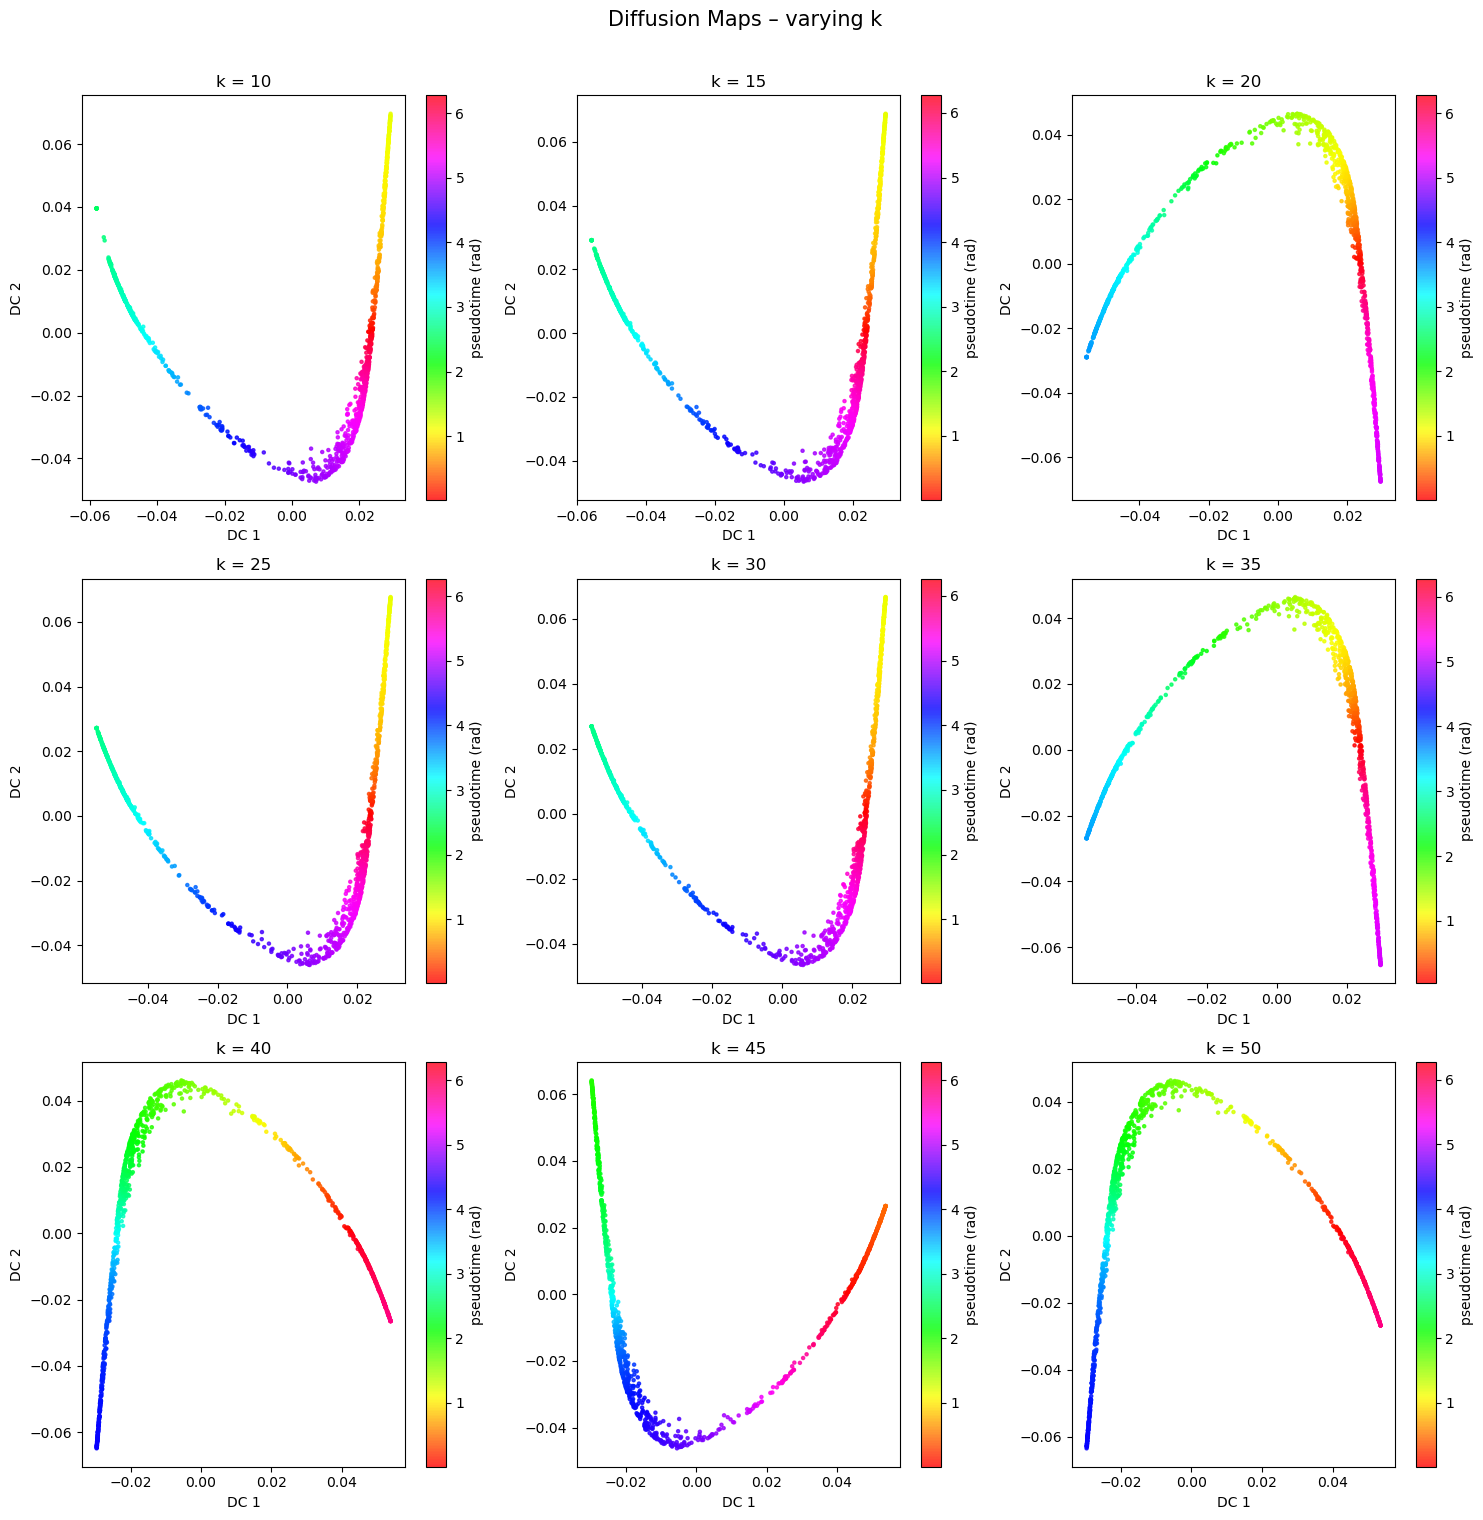

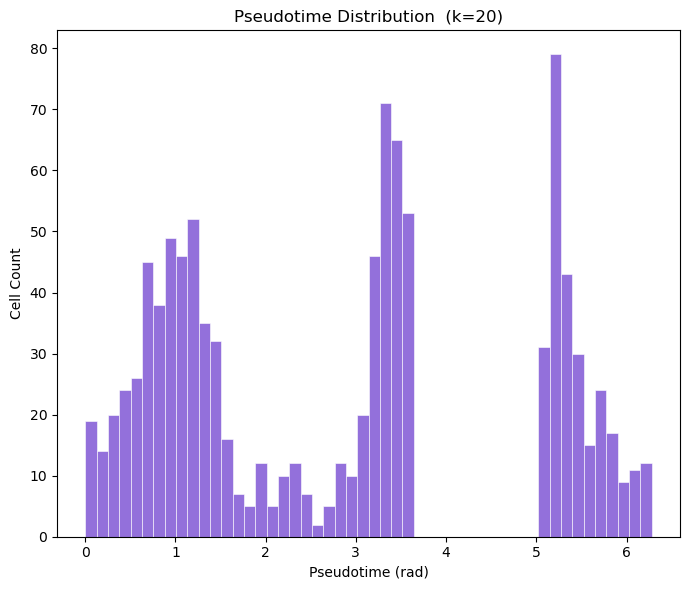

In [44]:
#load data
adata = sc.read_h5ad("/Users/anoushkasamuel/VSCode/src/cell-cycle-ti/data/wt_data.h5ad")
X     = adata.obsm['X_pca'][:, :30].astype(np.float32)
n, d  = X.shape

#eigenvalue ratio scan across k values


kVals = list(range(10, 55, 5))

print("Eigenvalue ratio scan (looking for ratio ≈ 1):")
print(f"{'k':>5}  {'λ1':>10}  {'λ2':>10}  {'λ2/λ1':>10}")
for k in kVals:
    _, K_scan = weighted_knn(DenseRows(n, d, X.flatten()), k=k)
    _, lambdas_scan, _ = diffusion_map(K_scan, n_components=5)
    ratio = lambdas_scan[1] / lambdas_scan[0] if lambdas_scan[0] != 0 else float('nan')
    print(f"k = {k:>2},  eigenvals = {np.round(lambdas_scan[:3], 4)},  eigenval ratio = {ratio:.4f}")

# ── Grid of diffusion maps + pseudotime for each k ────────────────────────────

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for i, k in enumerate(kVals):
    _, K_k = weighted_knn(DenseRows(n, d, X.flatten()), k=k)
    emb_k, _, _ = diffusion_map(K_k)
    ps_k = pseudotime(emb_k)

    if 'phase' in adata.obs.columns:
        color = adata.obs['phase'].cat.codes
        cmap  = 'tab10'
        label = 'phase'
    else:
        color = ps_k
        cmap  = 'hsv'
        label = 'pseudotime (rad)'

    sc_plot = axes[i].scatter(emb_k[:, 0], emb_k[:, 1],
                              c=color, cmap=cmap, s=5, alpha=0.8)
    axes[i].set_title(f"k = {k}", fontsize=12)
    axes[i].set_xlabel("DC 1")
    axes[i].set_ylabel("DC 2")
    plt.colorbar(sc_plot, ax=axes[i], label=label)

plt.suptitle("Diffusion Maps – varying k", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("/Users/anoushkasamuel/Downloads/diffmap_varying_k.png", dpi=150, bbox_inches='tight')
plt.show()
 
k_best = 20   # adjust after inspecting eigenvalue ratio scan
_, K   = weighted_knn(DenseRows(n, d, X.flatten()), k=k_best)
emb, _, _ = diffusion_map(K)
pseudo    = pseudotime(emb)

plt.figure(figsize=(7, 6))
plt.hist(pseudo, bins=50, color='mediumpurple', edgecolor='white', linewidth=0.4)
plt.xlabel("Pseudotime (rad)")
plt.ylabel("Cell Count")
plt.title(f"Pseudotime Distribution  (k={k_best})")
plt.tight_layout()
plt.savefig("/Users/anoushkasamuel/Downloads/diffmap_pseudotime_dist.png", dpi=150, bbox_inches='tight')
plt.show()
